In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,StandardScaler
from sklearn.metrics import root_mean_squared_error,mean_absolute_error, mean_squared_error,r2_score
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Dropout,Input
from keras.callbacks import EarlyStopping

In [2]:
df=pd.read_csv("Data/housing.csv")

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

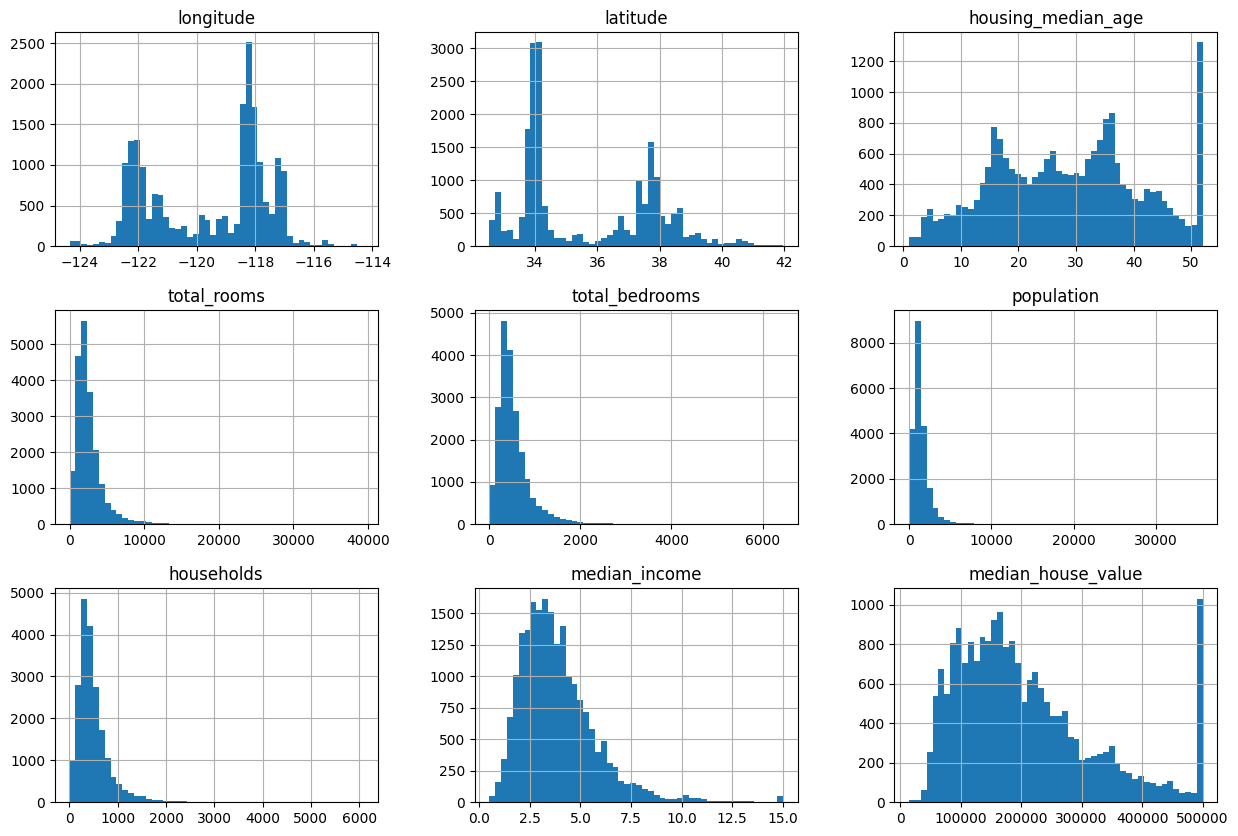

In [6]:
df.hist(bins=50,figsize=(15,10))
plt.show()

In [7]:
df["rooms_per_house"]=df["total_rooms"]/df["households"]
df["bedrooms_ratio"]=df["total_bedrooms"]/df["total_rooms"]
df["people_per_house"]=df["population"]/df["households"]

In [57]:
x = df.drop("median_house_value",axis=1)
y = df["median_house_value"]

In [58]:
x = pd.get_dummies(x,drop_first=True)

In [59]:
impute = SimpleImputer()
score = impute.fit_transform(x)
x = pd.DataFrame(data=score,columns=x.columns)

In [60]:
x

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_house,bedrooms_ratio,people_per_house,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,6.984127,0.146591,2.555556,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,6.238137,0.155797,2.109842,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,8.288136,0.129516,2.802260,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,5.817352,0.184458,2.547945,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,6.281853,0.172096,2.181467,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,5.045455,0.224625,2.560606,1.0,0.0,0.0,0.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,6.114035,0.215208,3.122807,1.0,0.0,0.0,0.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,5.205543,0.215173,2.325635,1.0,0.0,0.0,0.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,5.329513,0.219892,2.123209,1.0,0.0,0.0,0.0


In [61]:
columns = []
n_columns = []
for col in x.columns:
    if col.startswith("ocean"):
        n_columns.append(col)
    else:
        columns.append(col)
        

In [62]:
n_columns

['ocean_proximity_INLAND',
 'ocean_proximity_ISLAND',
 'ocean_proximity_NEAR BAY',
 'ocean_proximity_NEAR OCEAN']

In [63]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train,x_valid,y_train,y_valid = train_test_split(x_train,y_train,test_size=0.2,random_state=42)

In [64]:
x_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_house,bedrooms_ratio,people_per_house,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
16490,-120.97,38.00,27.0,1683.0,288.0,873.0,258.0,4.7069,6.523256,0.171123,3.383721,1.0,0.0,0.0,0.0
6090,-117.87,34.10,15.0,6409.0,1363.0,3359.0,1267.0,3.8750,5.058406,0.212670,2.651144,0.0,0.0,0.0,0.0
10973,-117.85,33.76,26.0,2312.0,525.0,1273.0,437.0,2.8828,5.290618,0.227076,2.913043,0.0,0.0,0.0,0.0
17287,-119.74,34.35,34.0,1664.0,292.0,705.0,257.0,5.0000,6.474708,0.175481,2.743191,0.0,0.0,0.0,1.0
12615,-121.51,38.50,25.0,4719.0,745.0,1857.0,739.0,5.0371,6.385656,0.157872,2.512855,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5606,-118.29,33.79,16.0,1867.0,571.0,951.0,498.0,3.3427,3.748996,0.305838,1.909639,0.0,0.0,0.0,0.0
16339,-121.34,38.04,16.0,3295.0,565.0,2279.0,576.0,3.6083,5.720486,0.171472,3.956597,1.0,0.0,0.0,0.0
14965,-116.99,32.74,18.0,3341.0,611.0,1952.0,602.0,3.9844,5.549834,0.182879,3.242525,0.0,0.0,0.0,0.0
11117,-117.87,33.84,16.0,1545.0,354.0,730.0,350.0,4.5112,4.414286,0.229126,2.085714,0.0,0.0,0.0,0.0


In [65]:
temp1 = x_train.copy()
temp2 = x_valid.copy()
temp3 = x_test.copy()
scaler = StandardScaler()
scale1 = scaler.fit_transform(x_train[columns])
scale2 = scaler.transform(x_valid[columns])
scale3 = scaler.transform(x_test[columns])
x_train = pd.DataFrame(data=scale1,columns=columns,index=temp1.index)
x_train[n_columns] = temp1[n_columns]
x_valid = pd.DataFrame(data=scale2,columns=columns,index=temp2.index)
x_valid[n_columns] = temp2[n_columns]
x_test = pd.DataFrame(data=scale3,columns=columns,index=temp3.index)
x_test[n_columns] = temp3[n_columns]

In [66]:
x_valid

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_house,bedrooms_ratio,people_per_house,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
2071,-0.133003,0.512312,0.510981,-0.672577,-0.839940,-0.782571,-0.843325,-0.175378,0.530241,-0.919609,-0.011503,1.0,0.0,0.0,0.0
2612,-2.282427,2.518158,-0.442233,-0.448731,-0.368267,-0.322657,-0.290158,-0.897615,-0.534805,0.296868,-0.045419,0.0,0.0,0.0,1.0
10838,0.829499,-0.926461,-1.157143,1.669664,2.761701,1.513479,2.898531,0.178941,-0.709539,0.976175,-0.152856,0.0,0.0,0.0,0.0
4061,0.565185,-0.701506,-1.474881,-0.719115,-0.670621,-0.800158,-0.619931,0.160738,-0.622432,0.435317,-0.158325,0.0,0.0,0.0,0.0
10767,0.839474,-0.945207,-0.045060,-0.123898,-0.448089,-0.523155,-0.404515,1.717549,0.665220,-1.108901,-0.092115,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18945,-1.220183,1.234042,-1.077709,1.153096,0.715369,0.871535,0.741711,0.327685,0.544072,-0.861885,0.011450,1.0,0.0,0.0,0.0
6011,0.904305,-0.743685,-0.124495,-0.213250,0.221927,0.837239,0.244393,-1.001328,-0.818862,1.303537,0.145218,1.0,0.0,0.0,0.0
10502,0.939215,-1.020192,-0.601102,-0.199289,-0.007862,-0.003444,-0.045488,-0.146804,-0.396183,0.496101,-0.011250,0.0,0.0,0.0,0.0
14688,1.248413,-1.334191,-0.283364,0.152071,0.035677,-0.232961,0.151312,-0.129077,-0.043072,-0.459253,-0.136990,0.0,0.0,0.0,1.0


In [67]:
def evaluation(pred):
    print("Analysis")
    print(f"RMSE: {root_mean_squared_error(y_test,pred)}")
    print(f"MAE : {mean_absolute_error(y_test,pred)}")
    print(f"MSE : {mean_squared_error(y_test,pred)}")
    print(f"R2  : {r2_score(y_test,pred)}")
    
    np.random.seed(42)
    indices = np.random.choice(len(y_test), 80, replace=False)
    
    actual = np.array(y_test)[indices]
    predicted = np.array(pred)[indices]
    plt.figure(figsize=(15,10))
    plt.plot(actual,marker='o', label="Actual")
    plt.plot(predicted,marker='o', label="Predicted")
    
    plt.xlabel("Sample")
    plt.ylabel("Value")
    plt.title("Actual vs Predicted Values")
    plt.legend()
    
    plt.show()

In [68]:
model = Sequential([
        Input(shape=(x_train.shape[1],)),
        Dense(120,activation="relu"),
        Dense(60,activation="relu"),
        Dense(30,activation="relu"),
        Dense(15,activation="relu"),
        Dense(8,activation="relu"),
        Dense(1,activation="linear")
    ]
)

In [69]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [70]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    mode="min",
    restore_best_weights=True,
    verbose=1
)
EPOCH = 50

In [71]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_valid,y_valid),
    epochs=EPOCH,
    callbacks=[early_stopping]
)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 37591687168.0000 - mae: 154534.9844 - val_loss: 11098621952.0000 - val_mae: 75588.6016
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 7794337280.0000 - mae: 63776.8789 - val_loss: 6984130560.0000 - val_mae: 59835.9102
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5761743360.0000 - mae: 54498.7109 - val_loss: 5606217216.0000 - val_mae: 53880.6836
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4968509952.0000 - mae: 50356.0234 - val_loss: 4947137536.0000 - val_mae: 50680.0664
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4564715008.0000 - mae: 48137.9414 - val_loss: 4647096320.0000 - val_mae: 48932.7773
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4354657280.0000 - mae: 46893.5742 - val_loss: 4528549376.0000 - val_mae: 48958.3672
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4243155968.0000 - mae: 46300.1055 - val_loss: 4430342144.0000 - val_mae: 

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Analysis
RMSE: 64181.09176736223
MAE : 45093.048400878906
MSE : 4119212540.450572
R2  : 0.6856544324062687


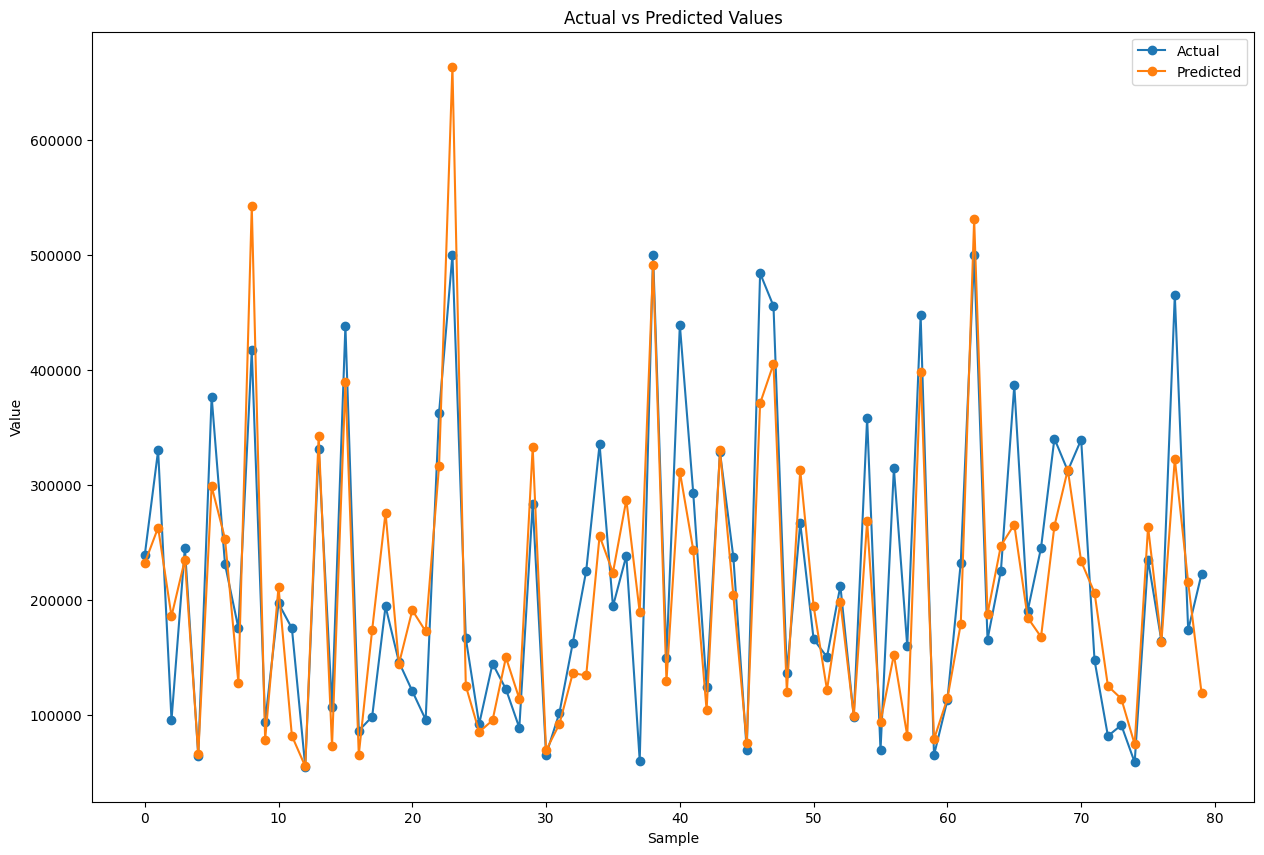

In [72]:
pred = model.predict(x_test)
evaluation(pred)